In [69]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

from sympy import *
from sympy.core import S

In [70]:

k, l = symbols('k, ell', positive=True, real=True)
B, b = symbols('B, b', real=True)
A = symbols('A', positive=True, real=True)
beta, H = symbols('beta, H', positive=True, real=True)

D = symbols('D', positive=True, integer=True)

ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*l) / (k*l / S(2))**(D/S(2) - S(1))
display(ftD)
OD = S(2)*pi**(D/S(2))/gamma(D/S(2))

acfD = exp(-A*l)
display(acfD.simplify())

ED = integrate(acfD * ftD * (k*l)**(D-1), (l, 0, oo)) * OD**2 / (S(2)*pi)**D

display(ED.simplify())
display(ED.simplify().subs({D: S(1)}).simplify())
display(ED.simplify().subs({D: S(2)}).simplify())
display(ED.simplify().subs({D: S(3)}).simplify())

eq_ED = (B/b) * S(1)/S(2) * l**2 * diff(2 * (S(1) - acfD), l)

#display(eq_ED.simplify())

display(eq_ED.simplify().subs({l: b/k}).simplify())

eq_EDk = eq_ED.simplify().subs({l: b/k}).simplify()


(ell*k/2)**(1 - D/2)*besselj(D/2 - 1, ell*k)*gamma(D/2)

exp(-A*ell)

2*A*k**(D - 1)*(A**2 + k**2)**(-D/2 - 1/2)*gamma(D/2 + 1/2)/(sqrt(pi)*gamma(D/2))

2*A/(pi*(A**2 + k**2))

A*k/(A**2 + k**2)**(3/2)

4*A*k**2/(pi*(A**2 + k**2)**2)

A*B*b*exp(-A*b/k)/k**2

In [71]:

bt = (k * diff(ln(ED), k)).simplify()
be = (k * diff(ln(eq_EDk), k)).simplify()

display(bt)
display(limit(bt, k, oo))
display(limit(bt, k, 0))

eqT = Eq(bt, 0)
points = solve(eqT, k)
for p in points:
    display(p.simplify())
    display(p.subs({D: S(1)}).simplify())
    display(p.subs({D: S(2)}).simplify())
    display(p.subs({D: S(3)}).simplify())

print('\n')

display(be)
display(limit(be, k, oo))
display(limit(be, k, 0))

eqE = Eq(be, 0)
points = solve(eqE, k)
for p in points:
    display(p.simplify())


(A**2*D - A**2 - 2*k**2)/(A**2 + k**2)

-2

(A**2*D - A**2)/A**2

A*sqrt(2*D - 2)/2

0

...

A

A*b/k - 2

-2

oo*sign(b)

A*b/2

In [72]:

E = (A/k)**beta

eq_ED = (B/b) * S(1)/S(2) * l**2 * diff(S(2)*integrate((S(1) - ftD)*E, (k, 0, oo)), l)

display(eq_ED.simplify().subs({beta: S(1) + S(2)*H, l: b/k}).simplify())

BIAS = (eq_ED.simplify().args[0][0].subs({l: b/k}).simplify()/E).simplify().subs({B: S(1)}).simplify()
display(BIAS)


Piecewise((B*b**(2*H)*(A/k)**(2*H + 1)*gamma(D/2)*gamma(1 - H)/(4**H*gamma(D/2 + H)), (H < 1) & (D + 4*H > 1)), (2**(D/2 - 1)*A**(2*H + 1)*B*b**(2 - D/2)*k**(D/2 - 3)*besselj(D/2, b)*gamma(D/2)*Integral(k**(-D/2 - 2*H + 1), (k, 0, oo)), True))

2*b**(beta - 1)*gamma(D/2)*gamma(3/2 - beta/2)/(2**beta*gamma(D/2 + beta/2 - 1/2))

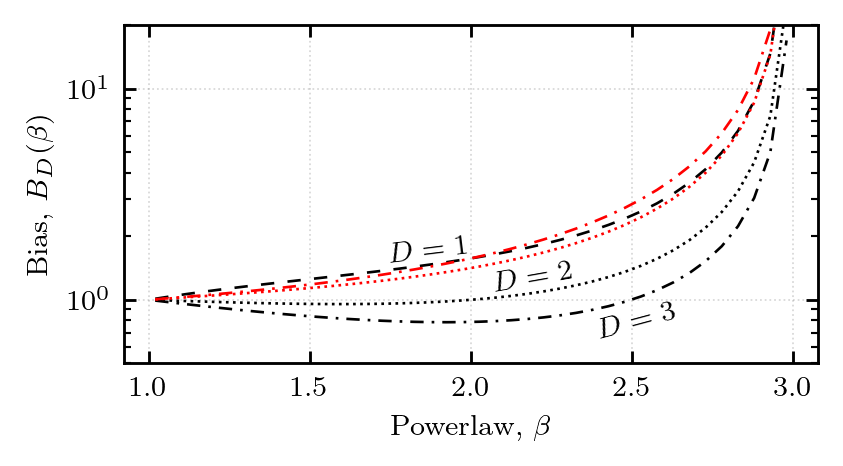

In [73]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

Ds = [1., 2., 3.]
Hs = np.linspace(0.01, 0.99, 40)

d_bias = []

for _d in Ds:
    vald = []
    for _hs in Hs:
        vald.append(np.float64(BIAS.subs({beta: 1. + 2.*_hs, D: _d, b: 1.}).evalf()))
    d_bias.append(np.array(vald))

ax.plot(1. + 2.*Hs, d_bias[0], linestyle=(0,(5,5)), color='black', linewidth=0.75, label='D=1')
ax.plot(1. + 2.*Hs, d_bias[1], linestyle=':', color='black', linewidth=0.75, label='D=2')
ax.plot(1. + 2.*Hs, d_bias[2], linestyle=(0,(5,3,1,3)), color='black', linewidth=0.75, label='D=3')


d_bias = []

for _d in [2., 3.]:
    vald = []
    __b = np.sqrt(2.*_d - 2.)
    for _hs in Hs:
        vald.append(np.float64(BIAS.subs({beta: 1. + 2.*_hs, D: _d, b: __b}).evalf()))
    d_bias.append(np.array(vald))

ax.plot(1. + 2.*Hs, d_bias[0], linestyle=':', color='red', linewidth=0.75, label='D=2')
ax.plot(1. + 2.*Hs, d_bias[1], linestyle=(0,(5,3,1,3)), color='red', linewidth=0.75, label='D=3')



ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')

ax.text(0.5, 0.385, r'$D=1$', transform=ax.transAxes, ha='right', va='top', rotation=7)
ax.text(0.65, 0.31, r'$D=2$', transform=ax.transAxes, ha='right', va='top', rotation=10)
ax.text(0.8, 0.19, r'$D=3$', transform=ax.transAxes, ha='right', va='top', rotation=15)

ax.set_xlabel(r'Powerlaw, $\beta$')
ax.set_ylabel(r'Bias, $B_D(\beta)$')

ax.set_ylim((5e-1, 20))

fig.savefig('plots/powerlaw_D_bias.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/powerlaw_D_bias.png', transparent=True, bbox_inches='tight', pad_inches=0)


In [102]:

k, l = symbols('k, ell', positive=True, real=True)
B, b = symbols('B, b', real=True)
A = symbols('A', positive=True, real=True)
beta, H = symbols('beta, H', positive=True, real=True)
u = symbols('u', positive=True, real=True)

D = symbols('D', positive=True, integer=True)
D = S(3)

ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*l) / (k*l / S(2))**(D/S(2) - S(1))
ftD = ftD.simplify()
display(ftD)
OD = S(2)*pi**(D/S(2))/gamma(D/S(2))

## INSTEAD, WE SAY THAT THE ACF IS THE LONGITUDINAL ONE
fD = exp(-A*l)
display(fD.simplify())
acfD = u**2 / (2 * l**2) * diff(l**3 * fD, l)
display(acfD.simplify())

ED = integrate(u**2 * fD * (sin(k*l)/(k*l) - cos(k*l))*(k*l)**2, (l, 0, oo)) * OD**2 / (2*pi)**3 / 2
ED2 = integrate(acfD * (sin(k*l)/(k*l)) * (k*l)**2, (l, 0, oo)) * OD**2 / (2*pi)**3

display(ED.simplify())
display(ED2.simplify())

eq_ED = Rational(1,2) * (B/b) * l**2 * diff(2 * (S(1) - acfD), l)
eq_EDk = eq_ED.simplify().subs({l: b/k}).simplify()
display(eq_EDk)


sin(ell*k)/(ell*k)

exp(-A*ell)

u**2*(-A*ell + 3)*exp(-A*ell)/2

8*A*k**4*u**2/(pi*(A**2 + k**2)**3)

8*A*k**4*u**2/(pi*(A**2 + k**2)**3)

A*B*b*u**2*(-A*b + 4*k)*exp(-A*b/k)/(2*k**3)

In [103]:

eq_EDp = Rational(3,4) * (B/b) * l**2 * diff(S(2) * (u**2 - u**2*fD), l)
eq_EDpk = eq_EDp.simplify().subs({l: b/k}).simplify()
display(eq_EDpk)


3*A*B*b*u**2*exp(-A*b/k)/(2*k**2)

In [90]:

beta_t = (k * diff(ln(ED), k)).simplify()
beta_e = (k * diff(ln(eq_EDk), k)).simplify()

display(beta_t)
#display(limit(beta_t, k, oo))
display(beta_e)
#display(limit(beta_e, k, oo))

for p in solve(Eq(beta_t, 0), k):
    display(p)
for p in solve(Eq(beta_e, 0), k):
    display(p)


2*(2*A**2 - k**2)/(A**2 + k**2)

(A**2*b**2 - 7*A*b*k + 8*k**2)/(k*(A*b - 4*k))

sqrt(2)*A

A*b*(7 - sqrt(17))/16

A*b*(sqrt(17) + 7)/16

In [95]:
display((sqrt(2) * 16 / (7 - sqrt(17))).evalf())
display((sqrt(2) * 16 / (7 + sqrt(17))).evalf())

7.86522341572848

2.03427152088318

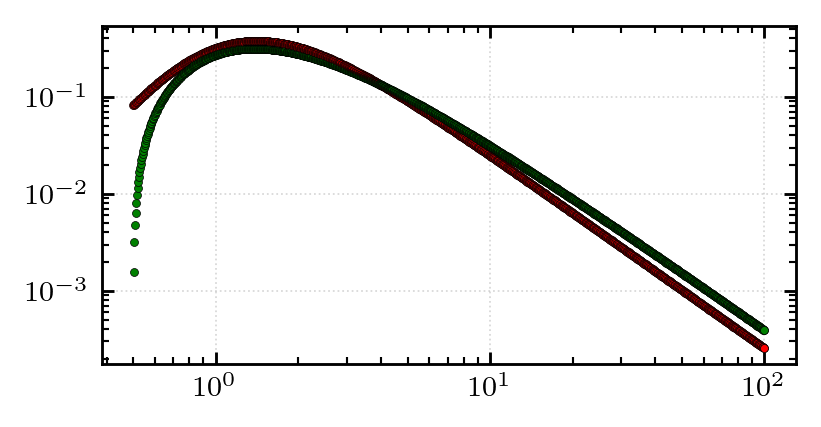

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

_k = np.exp(np.linspace(np.log(5e-1), np.log(1e2), 1000))

for __k in _k:
    spec1 = ED.subs({u: S(1), A: S(1), k: __k}).evalf()
    ax.scatter(__k, spec1, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')
    spec2 = eq_EDk.subs({B: S(1), b: S(2), A: S(1), u: S(1), k: __k}).evalf()
    ax.scatter(__k, spec2, marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')
ax.set_xscale('log')


In [56]:

# k, l = symbols('k, ell', positive=True, real=True)
# B, b = symbols('B, b', real=True)
# A = symbols('A', positive=True, real=True)
# beta, H = symbols('beta, H', positive=True, real=True)

# D = symbols('D', positive=True, integer=True)

# ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*l) / (k*l / S(2))**(D/S(2) - S(1))
# ftD = ftD.subs({D: S(1)}).simplify()
# display(ftD)

# ED = (S(2)/pi) * (A**S(2) / (A**S(2) + k**S(2)))**(beta/S(2))

# display(ED.simplify())

# eq_ED = (B/b) * S(1)/S(2) * l**2 * diff(S(2) * integrate((S(1) - ftD) * ED, (k, 0, oo)), l)
# eq_ED = eq_ED.simplify().args[0][0].subs({l: b/k}).simplify()
# display(eq_ED)
# eq_ED = eq_ED.subs({beta: S(1) + S(2)*H, B: S(1)}).simplify()
# display(eq_ED)

# beta_e = (k * diff(ln(eq_ED), k)).simplify()
# display(beta_e)

# #display(limit(beta_e, k, oo).simplify())
# #display(limit(beta_e, k, 0).simplify())


cos(ell*k)

2*(A/sqrt(A**2 + k**2))**beta/pi

sqrt(pi)*B*b**(beta/2 - 1/2)*k**(-beta/2 - 3/2)*(A/2)**(beta/2 + 1/2)*(A*b*besseli(3/2 - beta/2, A*b/k) + A*b*besseli(-beta/2 - 1/2, A*b/k) - A*b*besseli(beta/2 - 3/2, A*b/k) - A*b*besseli(beta/2 + 1/2, A*b/k) + beta*k*besseli(1/2 - beta/2, A*b/k) - beta*k*besseli(beta/2 - 1/2, A*b/k) - k*besseli(1/2 - beta/2, A*b/k) + k*besseli(beta/2 - 1/2, A*b/k))/(cos(pi*beta/2)*gamma(beta/2))

sqrt(pi)*b**H*k**(-H - 2)*(A/2)**(H + 1)*(-A*b*besseli(1 - H, A*b/k) - A*b*besseli(-H - 1, A*b/k) + A*b*besseli(H - 1, A*b/k) + A*b*besseli(H + 1, A*b/k) - 2*H*k*besseli(-H, A*b/k) + 2*H*k*besseli(H, A*b/k))/(sin(pi*H)*gamma(H + 1/2))

2**(-H - 2)*A**(-H - 1)*k**(-H - 5)*(-2**(H + 2)*A**(H + 1)*k**(H + 5)*(H + 2)*(A*b*besseli(1 - H, A*b/k) + A*b*besseli(-H - 1, A*b/k) - A*b*besseli(H - 1, A*b/k) - A*b*besseli(H + 1, A*b/k) + 2*H*k*besseli(-H, A*b/k) - 2*H*k*besseli(H, A*b/k)) + k**(H + 4)*(2*A)**(H + 1)*(A**2*b**2*(-2*besseli(-H, A*b/k) + 2*besseli(H, A*b/k) - besseli(2 - H, A*b/k) - besseli(-H - 2, A*b/k) + besseli(H - 2, A*b/k) + besseli(H + 2, A*b/k)) - 2*A*H*b*k*(besseli(1 - H, A*b/k) + besseli(-H - 1, A*b/k) - besseli(H - 1, A*b/k) - besseli(H + 1, A*b/k)) - 4*H*k**2*(-besseli(-H, A*b/k) + besseli(H, A*b/k))))/(A*b*besseli(1 - H, A*b/k) + A*b*besseli(-H - 1, A*b/k) - A*b*besseli(H - 1, A*b/k) - A*b*besseli(H + 1, A*b/k) + 2*H*k*besseli(-H, A*b/k) - 2*H*k*besseli(H, A*b/k))

In [57]:
# beta_e = (k * diff(ln(eq_ED), k)).simplify()#.expand(func=True).simplify()
# display(beta_e)

2**(-H - 2)*A**(-H - 1)*k**(-H - 5)*(-2**(H + 2)*A**(H + 1)*k**(H + 5)*(H + 2)*(A*b*besseli(1 - H, A*b/k) + A*b*besseli(-H - 1, A*b/k) - A*b*besseli(H - 1, A*b/k) - A*b*besseli(H + 1, A*b/k) + 2*H*k*besseli(-H, A*b/k) - 2*H*k*besseli(H, A*b/k)) + k**(H + 4)*(2*A)**(H + 1)*(A**2*b**2*(-2*besseli(-H, A*b/k) + 2*besseli(H, A*b/k) - besseli(2 - H, A*b/k) - besseli(-H - 2, A*b/k) + besseli(H - 2, A*b/k) + besseli(H + 2, A*b/k)) - 2*A*H*b*k*(besseli(1 - H, A*b/k) + besseli(-H - 1, A*b/k) - besseli(H - 1, A*b/k) - besseli(H + 1, A*b/k)) - 4*H*k**2*(-besseli(-H, A*b/k) + besseli(H, A*b/k))))/(A*b*besseli(1 - H, A*b/k) + A*b*besseli(-H - 1, A*b/k) - A*b*besseli(H - 1, A*b/k) - A*b*besseli(H + 1, A*b/k) + 2*H*k*besseli(-H, A*b/k) - 2*H*k*besseli(H, A*b/k))

In [68]:

# t = beta_e.subs({b: sqrt(S(2)*D - S(2)), k: A, H: Rational(1,2)}).simplify()
# display(t)
# display(t.subs({D: S(1)}).simplify())
# display(t.subs({D: S(2)}).simplify())
# display(t.subs({D: S(3)}).simplify())


sqrt(2)*(D - sqrt(2*D - 2) - 1)/sqrt(D - 1)

nan

-2 + sqrt(2)

0

In [65]:

# ke0 = Eq(beta_e.subs({H: Rational(1,2), b: sqrt(S(2)*D - S(2))}), 0)
# display(ke0)
# points = solve(ke0, k)
# for p in points:
#     display(p.simplify())


Eq(sqrt(2)*(-10*sqrt(2)*A**(3/2)*k**(11/2)*(A*sqrt(2*D - 2)*besseli(-3/2, A*sqrt(2*D - 2)/k) - A*sqrt(2*D - 2)*besseli(-1/2, A*sqrt(2*D - 2)/k) + A*sqrt(2*D - 2)*besseli(1/2, A*sqrt(2*D - 2)/k) - A*sqrt(2*D - 2)*besseli(3/2, A*sqrt(2*D - 2)/k) + k*besseli(-1/2, A*sqrt(2*D - 2)/k) - k*besseli(1/2, A*sqrt(2*D - 2)/k)) + 2*sqrt(2)*A**(3/2)*k**(9/2)*(A**2*(2*D - 2)*(-besseli(-5/2, A*sqrt(2*D - 2)/k) + besseli(-3/2, A*sqrt(2*D - 2)/k) - 2*besseli(-1/2, A*sqrt(2*D - 2)/k) + 2*besseli(1/2, A*sqrt(2*D - 2)/k) - besseli(3/2, A*sqrt(2*D - 2)/k) + besseli(5/2, A*sqrt(2*D - 2)/k)) - A*k*sqrt(2*D - 2)*(besseli(-3/2, A*sqrt(2*D - 2)/k) - besseli(-1/2, A*sqrt(2*D - 2)/k) + besseli(1/2, A*sqrt(2*D - 2)/k) - besseli(3/2, A*sqrt(2*D - 2)/k)) - 2*k**2*(-besseli(-1/2, A*sqrt(2*D - 2)/k) + besseli(1/2, A*sqrt(2*D - 2)/k))))/(8*A**(3/2)*k**(11/2)*(A*sqrt(2*D - 2)*besseli(-3/2, A*sqrt(2*D - 2)/k) - A*sqrt(2*D - 2)*besseli(-1/2, A*sqrt(2*D - 2)/k) + A*sqrt(2*D - 2)*besseli(1/2, A*sqrt(2*D - 2)/k) - A*sqrt(2*D

NotImplementedError: multiple generators [besseli(-1/2, A*sqrt(2*D - 2)/k), besseli(-3/2, A*sqrt(2*D - 2)/k), besseli(-5/2, A*sqrt(2*D - 2)/k), besseli(1/2, A*sqrt(2*D - 2)/k), besseli(3/2, A*sqrt(2*D - 2)/k), besseli(5/2, A*sqrt(2*D - 2)/k), sqrt(k)]
No algorithms are implemented to solve equation -10*sqrt(2)*A**(3/2)*k**(11/2)*(A*sqrt(2*D - 2)*besseli(-3/2, A*sqrt(2*D - 2)/k) - A*sqrt(2*D - 2)*besseli(-1/2, A*sqrt(2*D - 2)/k) + A*sqrt(2*D - 2)*besseli(1/2, A*sqrt(2*D - 2)/k) - A*sqrt(2*D - 2)*besseli(3/2, A*sqrt(2*D - 2)/k) + k*besseli(-1/2, A*sqrt(2*D - 2)/k) - k*besseli(1/2, A*sqrt(2*D - 2)/k)) + 2*sqrt(2)*A**(3/2)*k**(9/2)*(A**2*(2*D - 2)*(-besseli(-5/2, A*sqrt(2*D - 2)/k) + besseli(-3/2, A*sqrt(2*D - 2)/k) - 2*besseli(-1/2, A*sqrt(2*D - 2)/k) + 2*besseli(1/2, A*sqrt(2*D - 2)/k) - besseli(3/2, A*sqrt(2*D - 2)/k) + besseli(5/2, A*sqrt(2*D - 2)/k)) - A*k*sqrt(2*D - 2)*(besseli(-3/2, A*sqrt(2*D - 2)/k) - besseli(-1/2, A*sqrt(2*D - 2)/k) + besseli(1/2, A*sqrt(2*D - 2)/k) - besseli(3/2